## Generate the path gains with Sionna

In [155]:
import numpy as np
import mitsuba as mi
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

import sionna

from sionna.rt import load_scene, Camera, Transmitter, Receiver, PlanarArray,\
                      PathSolver, RadioMapSolver, load_mesh, watt_to_dbm, transform_mesh,\
                      cpx_abs_square

In [156]:
rm_solver = RadioMapSolver()

In [157]:
z = 30  # fixed height

def config_scene(num_rows, num_cols):
    """Load and configure a scene"""
    scene = load_scene(sionna.rt.scene.etoile)
    scene.bandwidth = 100e6

    # Configure antenna arrays for all transmitters and receivers
    scene.tx_array = PlanarArray(
        num_rows=num_rows,
        num_cols=num_cols,
        pattern="tr38901",
        polarization="V"
    )

    scene.rx_array = PlanarArray(
        num_rows=1,
        num_cols=1,
        pattern="iso",
        polarization="V"
    )

    # ---- Generate 100 transmitter positions ----
    num_tx = 100
    spacing = 20  # meters between transmitters (adjust)
    grid_size = int(np.ceil(np.sqrt(num_tx)))

    ################ scene.frequency=984e6 #####################

    positions = []
    look_ats = []

    for i in range(num_tx):
        row = i // grid_size
        col = i % grid_size

        x = -200 + col * spacing
        y = -200 + row * spacing

        positions.append([x,     y,     z])
        look_ats.append([0, 0, 0])   # all look toward center

    positions = np.array(positions)
    look_ats = np.array(look_ats)

    # Fixed power for all TX
    power_dbms = [23] * num_tx

    # Add all transmitters to scene
    for i in range(num_tx):
        scene.add(
            Transmitter(
                name=f"tx{i}",
                position=positions[i],
                look_at=look_ats[i],
                power_dbm=power_dbms[i]
            )
        )

    return scene

In [158]:
# Load and configure scene
num_rows=8
num_cols=2
scene = config_scene(num_rows, num_cols)

# Compute the SINR map
rm = rm_solver(scene,
               max_depth=5,
               samples_per_tx=10**7,
               cell_size=(1, 1))

In [159]:
scene.preview(radio_map=rm, rm_metric="path_gain")

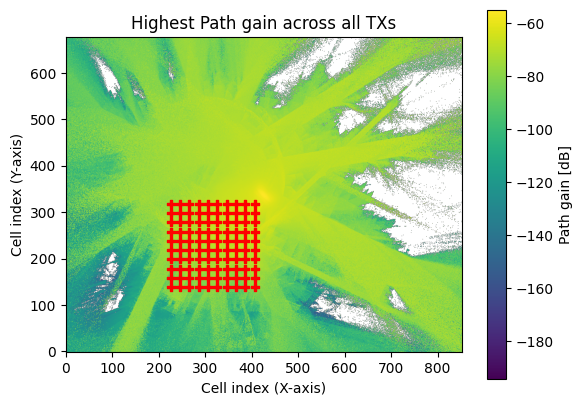

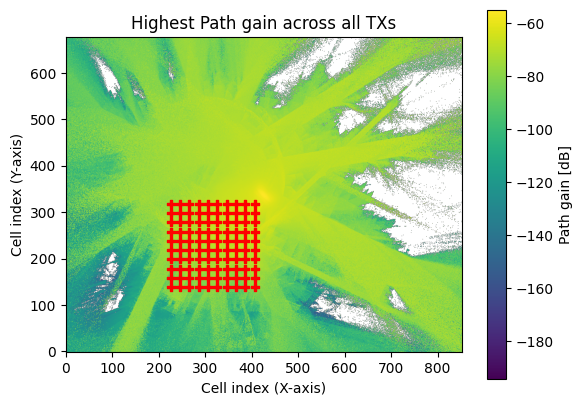

In [160]:
rm.show(metric="path_gain")

In [161]:
rm.tx_cell_indices # returns X / Y

[[226, 138],
 [246, 138],
 [266, 138],
 .. 94 skipped ..,
 [366, 318],
 [386, 318],
 [406, 318]]

In [162]:
rm.cell_centers[138][226] # expects Y / X

[-200.331, -199.56, 1.5]

In [163]:
rm.path_gain.shape

(100, 677, 854)

In [164]:
nTx = 27
x = rm.path_gain[nTx][138][226]
dB = 10*np.log10(x)

print(f"{x=}, {dB=}")

x=3.44917e-14, dB=-134.62285995483398


### Saving the files to use in NS3 (.bins with the path gains and coordinates.txt)

In [165]:
###### Files to calculate the PDR

# Save the radio map (dB) into a npy
path_gain_db = 10*np.log10(rm.path_gain)
for i in range(path_gain_db.shape[0]):
    filename = f"pgs_sionna/tx_{i}.bin"
    path_gain_db[i].tofile(filename)  # salva cada bloco em binário

coordinates = []
for y in range(rm.tx_cell_indices.shape[1]):
    base = rm.cell_centers[rm.tx_cell_indices[0][y]][rm.tx_cell_indices[1][y]]
    print(base)
    extra1 = rm.tx_cell_indices[0][y]
    extra2 = rm.tx_cell_indices[1][y]
    coordinates.append([*base, extra1, extra2])
    
# Salvar em arquivo de texto
with open("pgs_sionna/coordinates.txt", "w") as f:
    for c in coordinates:
        f.write(f"{c[1]},{c[0]},{z},{c[4]},{c[3]}\n") # Saving in the format (x, y) -> indexes

/tmp/ipykernel_1601960/3661725908.py:4: RuntimeWarning: divide by zero encountered in log10
  path_gain_db = 10*np.log10(rm.path_gain)


[-288.331, -111.56, 1.5]
[-288.331, -91.5603, 1.5]
[-288.331, -71.5603, 1.5]
[-288.331, -51.5603, 1.5]
[-288.331, -31.5603, 1.5]
[-288.331, -11.5603, 1.5]
[-288.331, 8.43973, 1.5]
[-288.331, 28.4397, 1.5]
[-288.331, 48.4397, 1.5]
[-288.331, 68.4397, 1.5]
[-268.331, -111.56, 1.5]
[-268.331, -91.5603, 1.5]
[-268.331, -71.5603, 1.5]
[-268.331, -51.5603, 1.5]
[-268.331, -31.5603, 1.5]
[-268.331, -11.5603, 1.5]
[-268.331, 8.43973, 1.5]
[-268.331, 28.4397, 1.5]
[-268.331, 48.4397, 1.5]
[-268.331, 68.4397, 1.5]
[-248.331, -111.56, 1.5]
[-248.331, -91.5603, 1.5]
[-248.331, -71.5603, 1.5]
[-248.331, -51.5603, 1.5]
[-248.331, -31.5603, 1.5]
[-248.331, -11.5603, 1.5]
[-248.331, 8.43973, 1.5]
[-248.331, 28.4397, 1.5]
[-248.331, 48.4397, 1.5]
[-248.331, 68.4397, 1.5]
[-228.331, -111.56, 1.5]
[-228.331, -91.5603, 1.5]
[-228.331, -71.5603, 1.5]
[-228.331, -51.5603, 1.5]
[-228.331, -31.5603, 1.5]
[-228.331, -11.5603, 1.5]
[-228.331, 8.43973, 1.5]
[-228.331, 28.4397, 1.5]
[-228.331, 48.4397, 1.5]
[-228

## Optimization

In [166]:
# Power threshold, PDR, X(Binary) ----------------- SF, Energy, TP - Future steps
# One gateway (X) -> Power constraint (min) (To decide) ->  MAX = One gateway per position

In [167]:
import pandas as pd

# read CSV
devices_df = pd.read_csv("end_devices_positions.csv", header=None)

# end_device positions -> cell indexes
end_devices_cells = list(zip(devices_df[3], devices_df[4]))

In [168]:
# Imports and seed
import numpy as np
import os
import re
import math
from pyomo.environ import *

# Defining the numpy seed
np.random.seed(0)

In [169]:
# Infos

# Transmission powers available
T = [10, 20, 30]

# SF parameter
Sfs = [7, 8, 9, 10, 11, 12]

P = [
    (-111.56, -288.331, 1.5),
    (-91.5603, -288.331, 1.5),
    (-71.5603, -288.331, 1.5),
    (-51.5603, -288.331, 1.5),
    (-31.5603, -288.331, 1.5),
    (-11.5603, -288.331, 1.5),
    (8.43973, -288.331, 1.5),
    (28.4397, -288.331, 1.5),
    (48.4397, -288.331, 1.5),
    (68.4397, -288.331, 1.5),

    (-111.56, -268.331, 1.5),
    (-91.5603, -268.331, 1.5),
    (-71.5603, -268.331, 1.5),
    (-51.5603, -268.331, 1.5),
    (-31.5603, -268.331, 1.5),
    (-11.5603, -268.331, 1.5),
    (8.43973, -268.331, 1.5),
    (28.4397, -268.331, 1.5),
    (48.4397, -268.331, 1.5),
    (68.4397, -268.331, 1.5),

    (-111.56, -248.331, 1.5),
    (-91.5603, -248.331, 1.5),
    (-71.5603, -248.331, 1.5),
    (-51.5603, -248.331, 1.5),
    (-31.5603, -248.331, 1.5),
    (-11.5603, -248.331, 1.5),
    (8.43973, -248.331, 1.5),
    (28.4397, -248.331, 1.5),
    (48.4397, -248.331, 1.5),
    (68.4397, -248.331, 1.5),

    (-111.56, -228.331, 1.5),
    (-91.5603, -228.331, 1.5),
    (-71.5603, -228.331, 1.5),
    (-51.5603, -228.331, 1.5),
    (-31.5603, -228.331, 1.5),
    (-11.5603, -228.331, 1.5),
    (8.43973, -228.331, 1.5),
    (28.4397, -228.331, 1.5),
    (48.4397, -228.331, 1.5),
    (68.4397, -228.331, 1.5),

    (-111.56, -208.331, 1.5),
    (-91.5603, -208.331, 1.5),
    (-71.5603, -208.331, 1.5),
    (-51.5603, -208.331, 1.5),
    (-31.5603, -208.331, 1.5),
    (-11.5603, -208.331, 1.5),
    (8.43973, -208.331, 1.5),
    (28.4397, -208.331, 1.5),
    (48.4397, -208.331, 1.5),
    (68.4397, -208.331, 1.5),

    (-111.56, -188.331, 1.5),
    (-91.5603, -188.331, 1.5),
    (-71.5603, -188.331, 1.5),
    (-51.5603, -188.331, 1.5),
    (-31.5603, -188.331, 1.5),
    (-11.5603, -188.331, 1.5),
    (8.43973, -188.331, 1.5),
    (28.4397, -188.331, 1.5),
    (48.4397, -188.331, 1.5),
    (68.4397, -188.331, 1.5),

    (-111.56, -168.331, 1.5),
    (-91.5603, -168.331, 1.5),
    (-71.5603, -168.331, 1.5),
    (-51.5603, -168.331, 1.5),
    (-31.5603, -168.331, 1.5),
    (-11.5603, -168.331, 1.5),
    (8.43973, -168.331, 1.5),
    (28.4397, -168.331, 1.5),
    (48.4397, -168.331, 1.5),
    (68.4397, -168.331, 1.5),

    (-111.56, -148.331, 1.5),
    (-91.5603, -148.331, 1.5),
    (-71.5603, -148.331, 1.5),
    (-51.5603, -148.331, 1.5),
    (-31.5603, -148.331, 1.5),
    (-11.5603, -148.331, 1.5),
    (8.43973, -148.331, 1.5),
    (28.4397, -148.331, 1.5),
    (48.4397, -148.331, 1.5),
    (68.4397, -148.331, 1.5),

    (-111.56, -128.331, 1.5),
    (-91.5603, -128.331, 1.5),
    (-71.5603, -128.331, 1.5),
    (-51.5603, -128.331, 1.5),
    (-31.5603, -128.331, 1.5),
    (-11.5603, -128.331, 1.5),
    (8.43973, -128.331, 1.5),
    (28.4397, -128.331, 1.5),
    (48.4397, -128.331, 1.5),
    (68.4397, -128.331, 1.5),

    (-111.56, -108.331, 1.5),
    (-91.5603, -108.331, 1.5),
    (-71.5603, -108.331, 1.5),
    (-51.5603, -108.331, 1.5),
    (-31.5603, -108.331, 1.5),
    (-11.5603, -108.331, 1.5),
    (8.43973, -108.331, 1.5),
    (28.4397, -108.331, 1.5),
    (48.4397, -108.331, 1.5),
    (68.4397, -108.331, 1.5),
]

In [ ]:
################## Adjust data from ns3 csvs (for example for nakagami) ##########################

nakagami_path_gain_db = []
PATH_GAIN_COLUMN = 3

def extract_number(filename):
    match = re.search(r'(\d+)', filename)
    return int(match.group(1)) if match else 999999

files = sorted(os.listdir("pgs_ns3/"), key=extract_number)

for fname in files:
    # print("Reading:", fname)
    df = pd.read_csv("pgs_ns3/" + fname, header=None)
    nakagami_path_gain_db.append(df)

# nakagami_path_gain_db[99][PATH_GAIN_COLUMN][0]

7.789099

In [ ]:
#### Pre-processing before the optimization #### 

path_gain_type = "nakagami" # nakagami

G = len(P) # Possibles gateway positions
rx_power = {}

for d, (ix, iy) in enumerate(end_devices_cells):
    for p_gateway in range(G): # Power that a ED receivers from each gateway in all positions available
        if path_gain_type == "sionna":
            rx_power[(d, p_gateway)] = float(path_gain_db[p_gateway][ix][iy]) 
        elif path_gain_type == "nakagami":
            rx_power[(d, p_gateway)] = float(nakagami_path_gain_db[p_gateway][PATH_GAIN_COLUMN][d])

# Solving -inf problem
NO_SIGNAL = -1000

for key, v in list(rx_power.items()):
    if v is None or math.isnan(v) or math.isinf(v):
        rx_power[key] = NO_SIGNAL # NO_SIGNAL replaces -inf values

G_index = list(range(G))       # 0..G-1
Nd = len(end_devices_cells)
D_index = list(range(Nd))      # 0..Nd-1

######################################################
P_min = 6  # threshold in dBm (to modify and re-run) #
######################################################

# Defining an cover dict
cover = {}
for d in D_index:
    for p_gateway in G_index:
        cover[(d, p_gateway)] = 1 if rx_power[(d, p_gateway)] >= P_min else 0 # This indicates whether the power threshold is being reached in each
                                                                              # end-device for each gateway -> simplification to 0 or 1

In [178]:
####### Optimizing the number of gateways based on a power threshold of the end-devices #########
 
model = ConcreteModel()

model.P = Set(initialize=G_index)   # all gateways positions = all positions
model.D = Set(initialize=D_index)   # devices

# Cover parameter as shown before
model.cover = Param(model.D, model.P, initialize=cover, within=Binary)

# Gateway positions (Set or Not)
model.x = Var(model.P, domain=Binary)

def coverage_rule(m, d):
    # At least one gateway must cover each end-device
    return sum(m.cover[d, p_gateway] * m.x[p_gateway] for p_gateway in m.P) >= 1

model.coverage = Constraint(model.D, rule=coverage_rule)

def obj_rule(m):
    return sum(m.x[p_gateway] for p_gateway in m.P)

model.obj = Objective(rule=obj_rule, sense=minimize)

model.pprint()

2 Set Declarations
    D : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :   20 : {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19}
    P : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :  100 : {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99}

1 Param Declarations
    cover : Size=2000, Index=D*P, Domain=Binary, Default=None, Mutable=False
        Key      : Value
          (0, 0) :     1
          (0, 1) :     0
          (0, 2) :     1
          (0, 3) :     1
          (0, 4) :     1
      

In [179]:
# SOLVER PART
solver = SolverFactory("glpk")
result = solver.solve(model) #, tee=True)

# Chosen gateways
chosen_gateways = [p for p in model.P if value(model.x[p]) > 0.5]

# Prints
print("\nGateways escolhidos (detalhes):")
for p in chosen_gateways:
    print(f"  p = {p}, coords = {P[p]}")


Gateways escolhidos (detalhes):
  p = 2, coords = (-71.5603, -288.331, 1.5)
  p = 36, coords = (8.43973, -228.331, 1.5)


In [180]:
#### Transforming to mW, adding the power values from each gateway and converting back to dB (for plots) ####

received_power = np.zeros(len(D_index))
for d in D_index:
    total_mW = 0.0
    for p in G_index:
        if value(model.x[p]) > 0.5:   # chosen gateway
            rp_dbm = rx_power[(d, p)]
            
            # converting dBm → mW
            rp_mw = 10**(rp_dbm / 10.0)
            
            total_mW += rp_mw
    
    # avoiding problem with log(0)
    if total_mW > 0:
        received_power[d] = 10 * np.log10(total_mW)   # back to dBm
    else:
        received_power[d] = NO_SIGNAL # very negative value

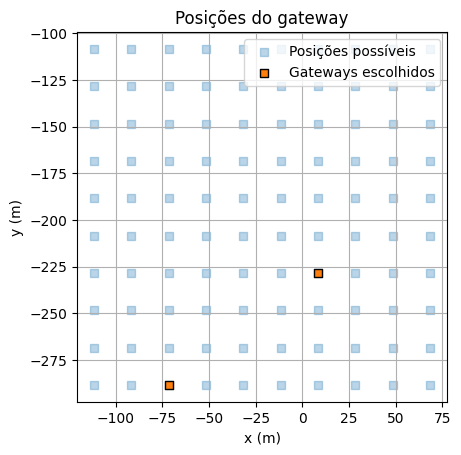

In [181]:
# Plotting

# gateways positions
xs_gate = [P[p][0] for p in G_index]
ys_gate = [P[p][1] for p in G_index]

# chosen gateways positions
xs_chosen = [P[p][0] for p in chosen_gateways]
ys_chosen = [P[p][1] for p in chosen_gateways]

plt.figure()
plt.scatter(xs_gate, ys_gate, marker='s', alpha=0.3, label='Posições possíveis')
plt.scatter(xs_chosen, ys_chosen, marker='s', edgecolors='k', label='Gateways escolhidos')

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Posições do gateway")
plt.legend()
plt.gca().set_aspect('equal', 'box')
plt.grid(True)
plt.show()


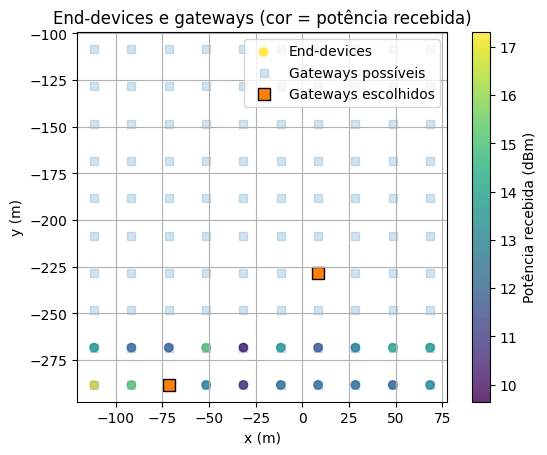

In [182]:
# Plotting with power

# End-device positions
dev_x = devices_df[0].values
dev_y = devices_df[1].values

plt.figure()

# end-devices coloridos pela potência recebida
sc = plt.scatter(dev_x, dev_y, c=received_power, alpha=0.8, label="End-devices")

# gateways possíveis (cinza claro)
plt.scatter(xs_gate, ys_gate, marker='s', alpha=0.2, label='Gateways possíveis')

# gateways escolhidos (destaque)
plt.scatter(xs_chosen, ys_chosen, marker='s', edgecolors='k', s=80, label='Gateways escolhidos')

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("End-devices e gateways (cor = potência recebida)")
plt.colorbar(sc, label="Potência recebida (dBm)")
plt.legend()
plt.gca().set_aspect('equal', 'box')
plt.grid(True)
plt.show()
